# Теория возмущений для осциллятора с медленно меняющейся частотой

## Условие задачи

Частота колебаний зависит от времени по закону
$$ \omega^2 = \omega_0^2 \left( 1 + \alpha e^{\lambda t} \right), $$
так что уравнение движения имеет вид
$$ \ddot{x} + \omega_0^2 \left( 1 + \alpha e^{\lambda t} \right) x = 0. $$
Требуется в первом порядке теории возмущений по малому параметру $|\alpha| \ll 1$ вычислить изменение адиабатического инварианта невозмущённых колебаний, соответствующих $\alpha = 0$.

## Аналитическое решение

Интегралом движения невозмущённой системы при $\alpha = 0$ является величина
$$ I_0 = \frac{\dot{x}^2 + \omega_0^2 x^2}{2\omega_0}. $$
Скорость её изменения в возмущённой системе находится дифференцированием по времени:
$$ \frac{dI_0}{dt} = \frac{1}{2\omega_0} \left( 2\dot{x}\ddot{x} + 2\omega_0^2 x \dot{x} \right) = \frac{\dot{x}}{\omega_0} \left( \ddot{x} + \omega_0^2 x \right). $$
Из уравнения движения $\ddot{x} + \omega_0^2 x = -\omega_0^2 \alpha e^{\lambda t} x$, и производная инварианта принимает вид
$$ \frac{dI_0}{dt} = -\alpha \omega_0 e^{\lambda t} x \dot{x}. $$
В первом порядке теории возмущений в правую часть подставляется решение невозмущённого уравнения
$$ x_0(t) = A \cos(\omega_0 t + \phi), \qquad \dot{x}_0(t) = -A \omega_0 \sin(\omega_0 t + \phi), $$
для которого
$$ x \dot{x} \approx x_0 \dot{x}_0 = -\frac{1}{2} A^2 \omega_0 \sin \left( 2\omega_0 t + 2\phi \right). $$
Для невозмущённого движения $I_0 = \frac{1}{2} \omega_0 A^2$, откуда $A^2 = 2I_0/\omega_0$ и $x \dot{x} \approx -I_0 \sin(2\omega_0 t + 2\phi)$.
Таким образом,
$$ \frac{dI_0}{dt} \approx \alpha \omega_0 I_0 e^{\lambda t} \sin \left( 2\omega_0 t + 2\phi \right). $$
Интегрирование по времени от $0$ до $t$, при котором $I_0$ в правой части считается постоянным, даёт
$$ \Delta I_0(t) = \alpha \omega_0 I_0 \int_0^t e^{\lambda \tau} \sin \left( 2\omega_0 \tau + 2\phi \right) d\tau. $$
С помощью табличного интеграла
$$ \int e^{a x} \sin(b x + c) \, dx = \frac{e^{a x}}{a^2 + b^2} \left[ a \sin(b x + c) - b \cos(b x + c) \right] $$
при $a = \lambda$, $b = 2\omega_0$, $c = 2\phi$ получается искомое изменение адиабатического инварианта в первом порядке:
$$ \Delta I_0(t) = \frac{\alpha \omega_0 I_0}{\lambda^2 + 4\omega_0^2} \left[ e^{\lambda \tau} \left( \lambda \sin(2\omega_0 \tau + 2\phi) - 2\omega_0 \cos(2\omega_0 \tau + 2\phi) \right) \right]_0^t. $$
Изменение инварианта осциллирует на удвоенной частоте колебаний, а амплитуда осцилляций растёт вместе с возмущением как $e^{\lambda t}$.

## Численный расчёт

Уравнение движения интегрируется численно методом Рунге–Кутты с высокой точностью, и изменение величины $I_0$ сравнивается с полученной формулой при $\alpha = 10^{-3}$, $\lambda = 0.2$ и начальных условиях $x(0) = 1$, $\dot{x}(0) = 0$, для которых $\phi = 0$.

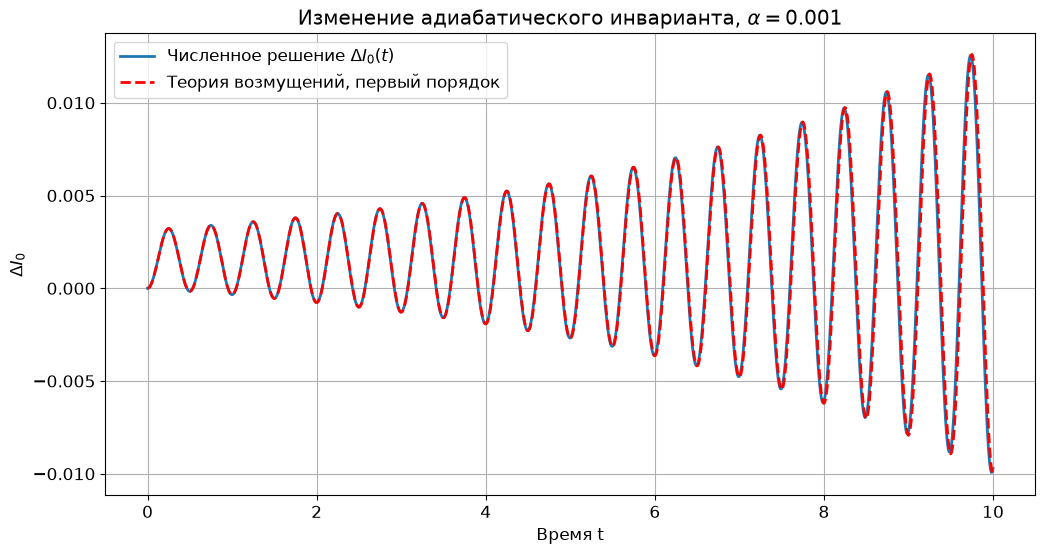

Максимальная ошибка: 2.167644e-03
Относительная ошибка к концу: 0.0336


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def system_dynamics(t, y, omega0, alpha, lam):
    """
    Система дифференциальных уравнений:
    dx/dt = v
    dv/dt = -omega0^2 * (1 + alpha * exp(lam * t)) * x
    """
    x, v = y
    dxdt = v
    dvdt = -omega0**2 * (1 + alpha * np.exp(lam * t)) * x
    return [dxdt, dvdt]

# Параметры
omega0 = 2 * np.pi * 1.0
alpha = 0.001  # Малое возмущение
lam = 0.2     # Скорость роста возмущения
t_max = 10.0
t_eval = np.linspace(0, t_max, 1000)

# Начальные условия
x0 = 1.0
v0 = 0.0
initial_state = [x0, v0]

# Численное решение
sol = solve_ivp(system_dynamics, [0, t_max], initial_state, t_eval=t_eval, args=(omega0, alpha, lam), rtol=1e-9, atol=1e-9)
x = sol.y[0]
v = sol.y[1]
t = sol.t

# Вычисление инварианта I0 (для невозмущенной системы)
I0_numeric = (v**2 + omega0**2 * x**2) / (2 * omega0)
I0_initial = I0_numeric[0]
Delta_I_numeric = I0_numeric - I0_initial

# Аналитическое предсказание изменения
# Начальная фаза phi. x0 = A cos(phi), v0 = -A w0 sin(phi).
# Если v0=0, то phi=0 (или pi), A=x0.
phi = 0
A = x0

def analytical_delta_I(t, omega0, alpha, lam, I0, phi):
    denom = lam**2 + 4*omega0**2
    
    term_t = np.exp(lam * t) * (lam * np.sin(2*omega0*t + 2*phi) - 2*omega0 * np.cos(2*omega0*t + 2*phi))
    term_0 = (lam * np.sin(2*phi) - 2*omega0 * np.cos(2*phi))
    
    return alpha * omega0 * I0 / denom * (term_t - term_0)

Delta_I_analytic = analytical_delta_I(t, omega0, alpha, lam, I0_initial, phi)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(t, Delta_I_numeric, label=r'Численное решение $\Delta I_0(t)$', linewidth=2)
plt.plot(t, Delta_I_analytic, 'r--', label='Теория возмущений, первый порядок', linewidth=2)
plt.title(rf'Изменение адиабатического инварианта, $\alpha = {alpha}$')
plt.xlabel('Время t')
plt.ylabel(r'$\Delta I_0$')
plt.legend()
plt.grid(True)
plt.show()

# Проверка ошибки
error = np.abs(Delta_I_numeric - Delta_I_analytic)
print(f"Максимальная ошибка: {np.max(error):.6e}")
print(f"Относительная ошибка к концу: {error[-1]/np.abs(Delta_I_numeric[-1]):.4f}")

## Итоги

Численное решение воспроизводит осцилляции инварианта на частоте $2\omega_0$ с амплитудой, растущей как $e^{\lambda t}$, в согласии с формулой первого порядка.
Расхождение к концу интервала обусловлено набегом фазы колебаний, не учитываемым в первом порядке: возмущение сдвигает частоту на $\delta\omega \approx \alpha \omega_0 e^{\lambda t}/2$, и накопленный сдвиг фазы $\delta\phi \approx \alpha \omega_0 (e^{\lambda t} - 1)/2\lambda$ составляет к моменту $t = 10$ около $0.1$ радиана.
Формула первого порядка применима, пока $\alpha \omega_0 e^{\lambda t} / \lambda \ll 1$.